In [1]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [37]:
REQ_DATA = 't_1.00_U_0.10_Vpp_0.800'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_200" in f]


In [38]:
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df


,psi,dV,mean_Sz,mean_fill,model_params
9,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",2.00,1.662954e-09,0.537318,"{'L': 2, 'U': 0.1, 'Vpm': 2.8, 'Vpp': 0.8, 'bc..."
7,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",2.60,-2.866732e-09,0.494836,"{'L': 2, 'U': 0.1, 'Vpm': 3.4000000000000004, ..."
5,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",2.90,-1.152106e-12,0.474758,"{'L': 2, 'U': 0.1, 'Vpm': 3.7, 'Vpp': 0.8, 'bc..."
1,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.00,1.869598e-12,0.467764,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc..."
3,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.05,5.361123e-12,0.464414,"{'L': 2, 'U': 0.1, 'Vpm': 3.8499999999999996, ..."
2,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.10,4.091120e-13,0.461221,"{'L': 2, 'U': 0.1, 'Vpm': 3.9000000000000004, ..."
4,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.15,-7.311483e-12,0.456972,"{'L': 2, 'U': 0.1, 'Vpm': 3.95, 'Vpp': 0.8, 'b..."
8,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.20,2.158875e-01,0.433017,"{'L': 2, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc..."
6,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.30,-2.081699e-01,0.416343,"{'L': 2, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc..."
0,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.40,-2.095697e-01,0.427220,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc..."


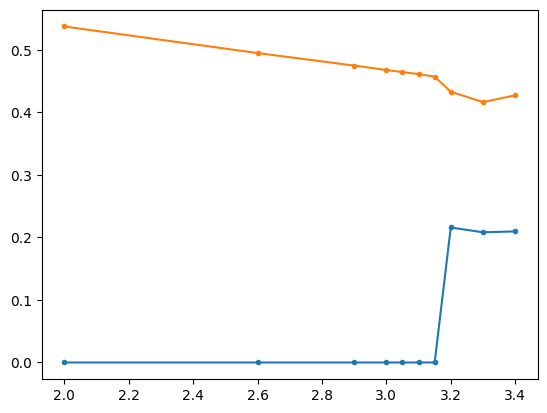

In [39]:
fig, ax = plt.subplots(1)
ax.plot(df['dV'], np.abs(df['mean_Sz']), '.-', c='C0')
ax.plot(df['dV'], np.abs(df['mean_fill']), '.-', c='C1')

computed Kc =  0.3186966416953428
naive bosonization Kc =  (0.6519374414908893+0j)


/tmp/ipykernel_1833578/335201994.py:8: RuntimeWarning: divide by zero encountered in power
  plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")


0.6908723080762551

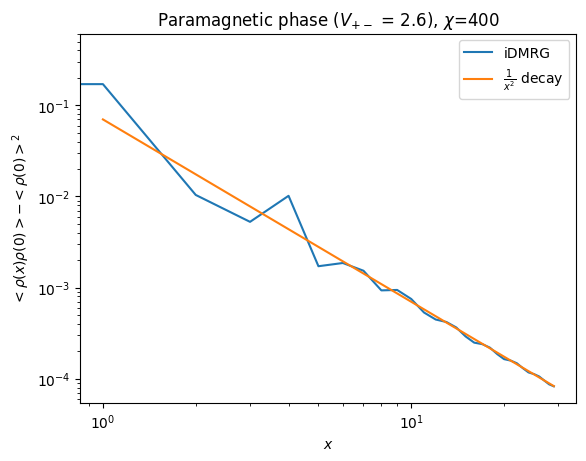

In [45]:
psipm = df[np.isclose(df['dV'], 2.60)]['psi'].iloc[0]
distrange = 30
charge_corr_pm = observables.charge_corr(psipm, length=distrange, connected=True)
charge_corr_pm_w_sign =  psipm.correlation_function("Ntot", "Ntot", [0], distrange)[0] - (psipm.expectation_value("Ntot")[0])**2
calc_Kc = (np.pi / 2.0) * np.sum(charge_corr_pm_w_sign)
bosn_Kc ,bosn_Ks = compute_Luttinger_parameter(1, 0.1, 0.8, 0.8 + 2.60)
plt.plot(charge_corr_pm, label="iDMRG")
plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")
plt.yscale('log')
plt.xscale('log')
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<\rho(x) \rho(0)> - <\rho(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()
print("computed Kc = ", calc_Kc)
print("naive bosonization Kc = ", bosn_Kc)
0.07 * np.pi**2

In [56]:
ft = np.array([np.sum(np.exp(2*np.pi*1j * np.arange(distrange) * kint / distrange) * charge_corr_pm_w_sign) for kint in np.arange(distrange)])
kvals = 2 * np.pi / distrange * np.arange(distrange)
grads = np.gradient(ft, kvals)
np.pi * grads[0]

np.complex128(0.3046003680238664-0.7640769434471203j)

/tmp/ipykernel_1833578/717278757.py:3: RuntimeWarning: divide by zero encountered in power
  plt.plot(0.06 * (np.arange(distrange,dtype=float)[0:])**-2, label=r"$\frac{1}{x^2}$ decay")


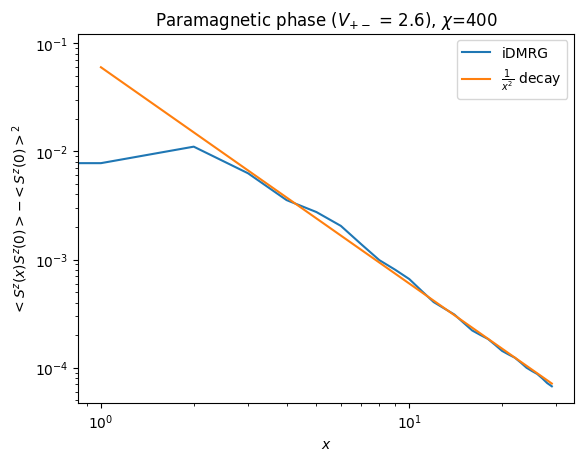

In [24]:
distrange = 30
plt.plot(observables.SzSz_corr(psipm, length=distrange, connected=True), label="iDMRG")
plt.plot(0.06 * (np.arange(distrange,dtype=float)[0:])**-2, label=r"$\frac{1}{x^2}$ decay")
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<S^z(x) S^z(0)> - <S^z(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [25]:
psifm = df[np.isclose(df['dV'], 3.4)]['psi'].iloc[0]
distrange = 30
fmspincorr = observables.SzSz_corr(psifm, length=distrange, connected=True)
fmchargecorr = observables.charge_corr(psifm, length=distrange, connected=True)

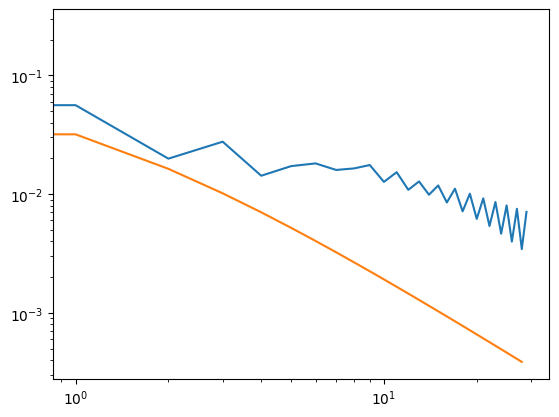

In [26]:
plt.plot(fmchargecorr)
plt.plot(0.1 * (np.arange(distrange, dtype=float)[1:]**(-1.65)))
plt.yscale('log')
plt.xscale('log')

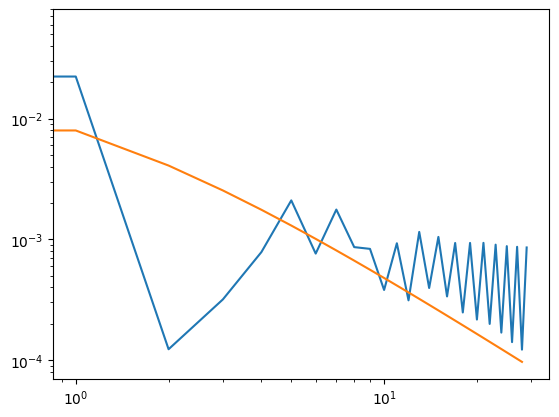

In [ ]:
distrange = 30
plt.plot(fmspincorr)
# plt.plot(0.025 * (np.arange(distrange)[1:])**-1.65)
plt.yscale('log')
plt.xscale('log')

In [ ]:
ser_psi = df[np.isclose(df['dV'], 2.9)]
psitest  = ser_psi['psi'].iloc[0]
test_model_params = ser_psi['model_params'].iloc[0]
parat, paraU, paraVpp, paraVpm = test_model_params['t'], test_model_params['U'], test_model_params['Vpp'], test_model_params['Vpm']
compute_Luttinger_parameter(parat, paraU, paraVpp, paraVpm)

((0.6390970286164492+0j), (4.049351809334104+0j))

In [ ]:
psifm.correlation_length2(), psipm.correlation_length2()

(np.float64(344.82118938891966), np.float64(36.18109209143194))

In [ ]:
longdistcorrfmspin = observables.SzSz_corr(psifm, length=1000, connected=True) #correlation length is 344


KeyboardInterrupt: 

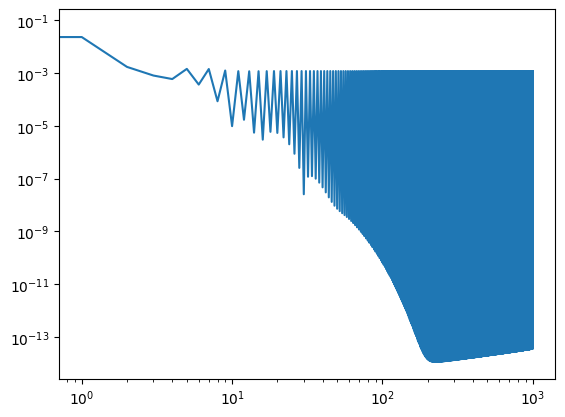

In [ ]:
plt.loglog(longdistcorrfmspin)

ModuleNotFoundError: No module named 'tenpy_dmrg'

In [36]:
np.arange(3.0, 3.3, 0.01)

array([3.  , 3.01, 3.02, 3.03, 3.04, 3.05, 3.06, 3.07, 3.08, 3.09, 3.1 ,
       3.11, 3.12, 3.13, 3.14, 3.15, 3.16, 3.17, 3.18, 3.19, 3.2 , 3.21,
       3.22, 3.23, 3.24, 3.25, 3.26, 3.27, 3.28, 3.29])

array([0.49485292, 0.49485292])